## Isolation Forest (Clustering)

Isolation Forest is an unsupervised machine learning algorithm designed specifically for anomaly detection. Unlike other algorithms that learn "normal" behavior (and flag anything different), Isolation Forest directly isolates "anomalies."

Isolation Forest builds multiple random decision trees. In each tree, the algorithm recursively splits the data by randomly selecting a feature and a split value.

The key metric is the average path length from the root of the tree to the leaf node where a data point ends. By averaging the path lengths over many trees, the algorithm calculates an Anomaly Score. A score close to 1 indicates a high probability of being an anomaly, while a score less than 0.5 indicates a normal point.


1 Setup libraries

In [1]:
import json
import pandas as pd
import joblib
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


Defines where to read the processed data from (data_processed.json) and where to save the results (data_labeled.json).

In [2]:
input_file = "../data/data_2/data_processed.json"
output_file = "../data/data_2/data_labeled.json"

2 Read data

Loads the processed transaction data and extracts Hour and DayOfWeek from the timestamp column so the model can use time as a signal.

In [3]:
# Read data
df = pd.read_json(input_file)

if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

df.head() 


,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month),Age,Balance_to_Salary_Ratio,Transaction_to_Balance_Ratio,Hour,DayOfWeek
0,TXN_300001,ACC_06255,REC_3912,0.436816,2025-11-17 07:34:00,3,1,4,2,1,0.252505,10,2,0.177778,0.414634,0.097504,0.003572,7,0
1,TXN_300002,ACC_04472,REC_7262,0.168972,2025-08-13 07:31:00,1,1,3,1,6,0.088176,3,5,0.355556,0.170732,0.021225,0.003929,7,2
2,TXN_300003,ACC_00398,REC_3277,0.309114,2025-01-24 15:14:00,1,1,3,0,0,0.326653,4,5,0.266667,0.463415,0.096282,0.001959,15,4
3,TXN_300004,ACC_06061,REC_4510,0.923370,2025-08-16 20:45:00,6,2,2,2,6,0.462926,2,2,0.933333,0.926829,0.049164,0.004124,20,5
4,TXN_300005,ACC_09143,REC_4206,0.368501,2025-05-06 21:27:00,0,2,2,0,5,0.749499,2,3,0.377778,0.048780,0.170282,0.001018,21,1


3 Picking features 

Selects the columns the model will use to learn patterns — things like transaction amount, account balance, salary, time of day, and demographic info.

In [4]:
features = [
    'Transaction amount', 'Account balance', 'Salary (per month)',
    'Hour', 'DayOfWeek', 'Age', 'Is_Weekend', 'Is_Night',
    'Balance_to_Salary_Ratio', 'Transaction_to_Balance_Ratio',
    'Transaction Detail', 'Geological', 'Device Use', 
    'Location', 'Working Status', 'Gender', 'Transaction Count'
]

selected_features = [col for col in features if col in df.columns]
X = df[selected_features]

4 Train model

Creates and trains the Isolation Forest model. It uses 100 decision trees and assumes 15% of all transactions are suspicious (contamination=0.15).

In [5]:
model = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.15
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


Save model

In [6]:
joblib.dump(model, '../models/isolation_forest.pkl')

['../models/isolation_forest.pkl']

Number of Anomalies

In [7]:
predictions = model.predict(X)
df['is_fraud'] = [1 if p == -1 else 0 for p in predictions]
df['anomaly_score'] = model.score_samples(X)
print(f"Found {df['is_fraud'].sum()} suspicious transactions.")


Found 3750 suspicious transactions.


5 Saving result to json file (data_labeled)

The model scores every transaction. Anything flagged as an anomaly (-1) gets labeled as fraud (1), everything else as normal (0). It also stores a raw anomaly score for each row.

First Block (if): This checks if the column 'DateTime' exists in the DataFrame and converts all its values into strings to ensure data type consistency.

Second Block (elif): This serves as a fallback that checks for a 'Timestamp' column and converts it to strings only if the 'DateTime' column was not found.

In [8]:

if 'DateTime' in df.columns:
    df['DateTime'] = df['DateTime'].astype(str)
elif 'Timestamp' in df.columns:
    df['Timestamp'] = df['Timestamp'].astype(str)
    
df.to_json(output_file, orient='records', indent=4, force_ascii=False)


6 Visualization


6.1 Anomaly Score Distribution 

A histogram showing normal transactions on the right and fraud on the left, split by a red threshold line

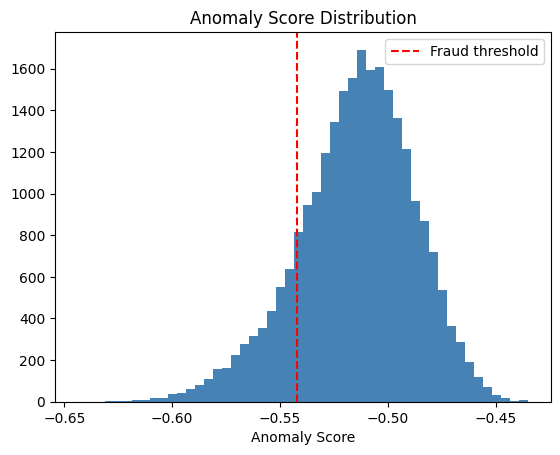

In [9]:
import matplotlib.pyplot as plt
plt.hist(df['anomaly_score'], bins=50, color='steelblue')
plt.axvline(df[df['is_fraud']==1]['anomaly_score'].max(), color='red', linestyle='--', label='Fraud threshold')
plt.title('Anomaly Score Distribution')
plt.xlabel('Anomaly Score'); plt.legend(); plt.show()

6.2 Fraud vs Normal Count (Bar Chart)

How many transactions were flagged as fraud vs normal

Text(0.5, 1.0, 'Normal vs Fraud Count')

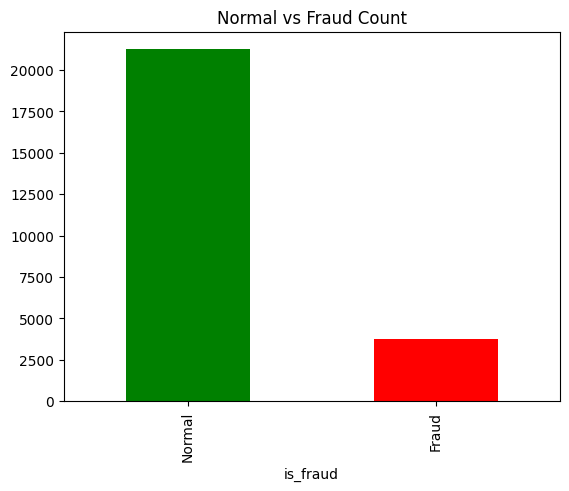

In [10]:
df['is_fraud'].value_counts().rename({0:'Normal', 1:'Fraud'}).plot(kind='bar', color=['green','red'])
plt.title('Normal vs Fraud Count')


6.3 Transaction Amount vs Account Balance (Scatter Plot)

Each transaction as a dot — fraudulent ones are highlighted to reveal suspicious patterns (e.g., large amounts with a near-empty account)

Text(0.5, 1.0, 'Transaction Amount vs Account Balance')

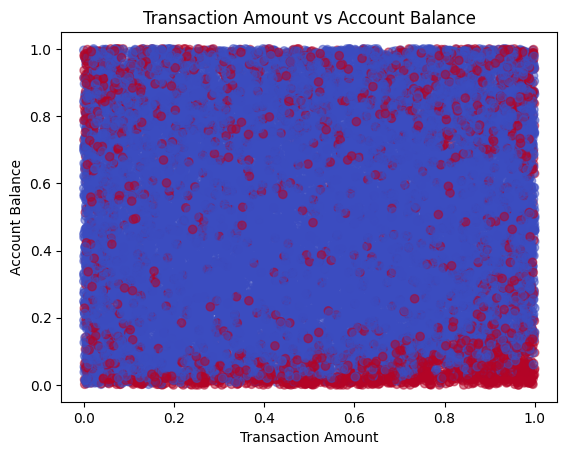

In [11]:
plt.scatter(df['Transaction amount'], df['Account balance'], c=df['is_fraud'], cmap='coolwarm', alpha=0.5)
plt.xlabel('Transaction Amount'); plt.ylabel('Account Balance')
plt.title('Transaction Amount vs Account Balance')


6.4 Anomaly Heatmap by Hour and Day of Week

A grid showing when fraud tends to happen, which hour and which day of the week

Text(0.5, 1.0, 'Fraud Heatmap: Hour vs Day of Week')

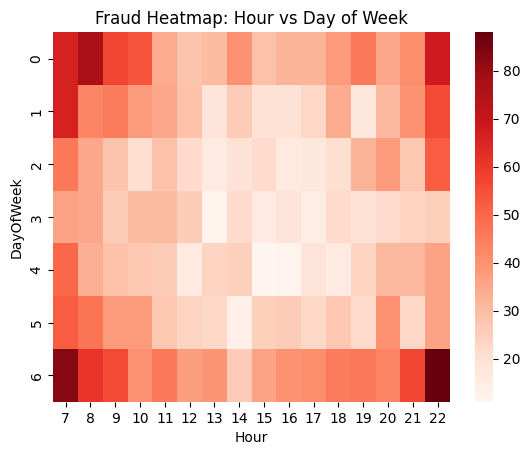

In [12]:
import seaborn as sns
pivot = df[df['is_fraud']==1].groupby(['DayOfWeek','Hour']).size().unstack(fill_value=0)
sns.heatmap(pivot, cmap='Reds')
plt.title('Fraud Heatmap: Hour vs Day of Week')
